In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

On charge le fichier mobile-data.csv puis on sépare les variables explicatives X (20 colonnes) de la cible y (price_range), ce qui prépare le jeu de données pour la suite de l’analyse et la classification.

In [2]:
# Charger le dataset
data = pd.read_csv("D:/imen-chabchoub/FAC/BDIA2-2/data-mining/datamining1/data/raw/mobile-data.csv")

# Séparer features et cible
X = data.drop(columns=["price_range"])
y = data["price_range"].copy()

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)
print("Classes de prix :", y.value_counts())

Forme de X : (2000, 20)
Forme de y : (2000,)
Classes de prix : price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


On vérifie que toutes les colonnes sont bien numériques et qu’il n’y a aucune valeur manquante, ce qui confirme que le dataset est propre et prêt pour l’ACP et la modélisation.

In [3]:
# Vérifier les types (tout doit être numérique)
print(X.dtypes)
print(X.isnull().sum().sum())  # 0 = OK

# Information sur la cible
print(y.value_counts(normalize=True).round(3))

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
dtype: object
0
price_range
1    0.25
2    0.25
3    0.25
0    0.25
Name: proportion, dtype: float64


On divise le dataset en ensemble d’entraînement et de test (80% / 20%) en gardant la même répartition des 4 classes de prix (stratify=y), afin de pouvoir évaluer de façon fiable ton modèle de classification plus tard.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # maintient la répartition des 4 classes
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.value_counts())
print("y_test  :", y_test.value_counts())

X_train : (1600, 20)
X_test  : (400, 20)
y_train : price_range
1    400
0    400
3    400
2    400
Name: count, dtype: int64
y_test  : price_range
3    100
1    100
0    100
2    100
Name: count, dtype: int64


On sélectionne uniquement les variables numériques continues (batterie, RAM, mémoire, pixels, etc.) pour l’ACP, car ce sont ces caractéristiques qui varient le plus et peuvent bien expliquer la diversité des smartphones.

In [5]:
# Colonnes numériques continues pour l'ACP
cols_acp = [
    "battery_power",
    "clock_speed",
    "int_memory",
    "mobile_wt",
    "n_cores",
    "pc",
    "fc",
    "px_height",
    "px_width",
    "ram",
    "sc_h",
    "sc_w",
    "talk_time"
]

print("Variables pour l'ACP :")
print(cols_acp)

Variables pour l'ACP :
['battery_power', 'clock_speed', 'int_memory', 'mobile_wt', 'n_cores', 'pc', 'fc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']


On centre‑réduit (StandardScaler) les variables continues pour que toutes aient la même échelle (moyenne ≈ 0, écart‑type ≈ 1), ce qui est nécessaire pour une ACP correcte et équitable sur toutes les variables.

In [6]:
from sklearn.preprocessing import StandardScaler

# Copie standardisée pour l'ACP et les modèles sensibles à l'échelle
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[cols_acp] = scaler.fit_transform(X_scaled[cols_acp])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_acp] = scaler.transform(X_train_scaled[cols_acp])
X_test_scaled[cols_acp]  = scaler.transform(X_test_scaled[cols_acp])

print("Vérification X_scaled :")
print(X_scaled[cols_acp].describe())

Vérification X_scaled :
       battery_power   clock_speed    int_memory     mobile_wt       n_cores  \
count   2.000000e+03  2.000000e+03  2.000000e+03  2.000000e+03  2.000000e+03   
mean    2.149392e-16 -1.545430e-16 -9.592327e-17  1.278977e-16 -7.727152e-17   
std     1.000250e+00  1.000250e+00  1.000250e+00  1.000250e+00  1.000250e+00   
min    -1.678817e+00 -1.253064e+00 -1.656260e+00 -1.702391e+00 -1.539175e+00   
25%    -8.804033e-01 -1.007906e+00 -8.845346e-01 -8.829695e-01 -6.647678e-01   
50%    -2.849593e-02 -2.727384e-02 -2.563229e-03  2.122020e-02 -2.275644e-01   
75%     8.575560e-01  8.307794e-01  8.794082e-01  8.406421e-01  1.084046e+00   
max     1.728812e+00  1.811412e+00  1.761380e+00  1.688320e+00  1.521249e+00   

                 pc            fc     px_height      px_width           ram  \
count  2.000000e+03  2.000000e+03  2.000000e+03  2.000000e+03  2.000000e+03   
mean   1.403322e-16  5.861978e-17  1.181277e-16  6.084022e-17 -1.811884e-16   
std    1.000250e+0

On applique l’ACP sur les variables standardisées et on calcule la variance expliquée par chaque axe ; on voit que les 10 premiers axes capturent près de 90% de la variance, tandis que les 2 premiers en capturent environ 25%.

In [7]:
from sklearn.decomposition import PCA

# Appliquer l'ACP sur les colonnes numériques continues
pca = PCA()
X_pca = pca.fit_transform(X_scaled[cols_acp])

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained variance ratio par axe :")
print("Premiers 10 axes :", np.round(explained_variance[:10], 3))
print("Variance cumulée  :", np.round(cumulative_variance[:10], 3))

Explained variance ratio par axe :
Premiers 10 axes : [0.128 0.122 0.111 0.081 0.08  0.079 0.077 0.076 0.073 0.071]
Variance cumulée  : [0.128 0.25  0.361 0.442 0.522 0.601 0.678 0.754 0.827 0.898]


On ne garde que les 2 premiers axes de l’ACP pour la visualisation, ce qui donne une matrice X_pca_2 de dimension (2000 × 2) suffisamment simple à représenter tout en conservant une partie de la structure des données.

In [8]:
# Conserver les 2 premiers axes pour la visualisation
n_components = 2
pca_2 = PCA(n_components=n_components)
X_pca_2 = pca_2.fit_transform(X_scaled[cols_acp])

print("Forme de X_pca_2 :", X_pca_2.shape)
print("Variance expliquée par 2 axes :", cumulative_variance[n_components-1])

Forme de X_pca_2 : (2000, 2)
Variance expliquée par 2 axes : 0.24997681441938407


On affiche les points projetés sur (PC1, PC2), colorés par price_range, ce qui permet de voir si les classes de prix se séparent mieux ou se mélangent dans ce plan factoriel.

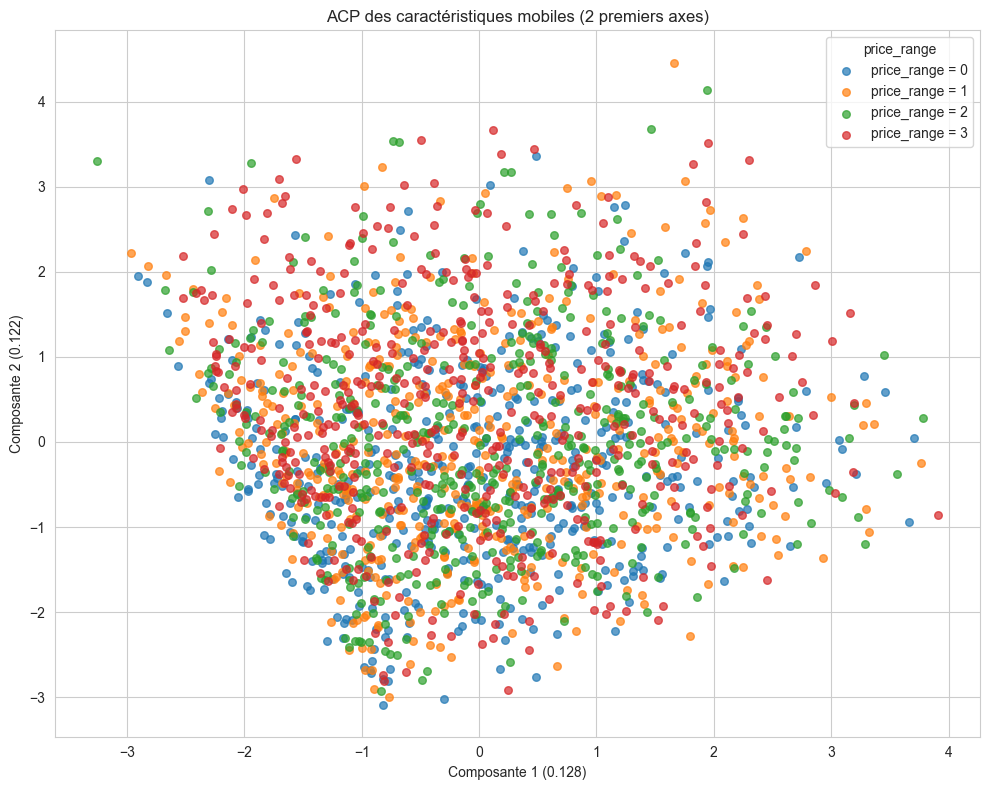

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for cls in sorted(y.unique()):
    mask = (y == cls)
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1],
                label=f"price_range = {cls}",
                alpha=0.7,
                s=30)

plt.xlabel(f"Composante 1 ({pca.explained_variance_ratio_[0]:.3f})")
plt.ylabel(f"Composante 2 ({pca.explained_variance_ratio_[1]:.3f})")
plt.title("ACP des caractéristiques mobiles (2 premiers axes)")
plt.legend(title="price_range")
plt.grid(True)
plt.tight_layout()
plt.show()

On applique KMeans avec 4 clusters sur les 2 axes de l’ACP, puis on ajoute ces clusters au dataset; on constate alors comment le regroupement non supervisé est réparti entre les différentes classes de prix.

<Figure size 1000x600 with 0 Axes>

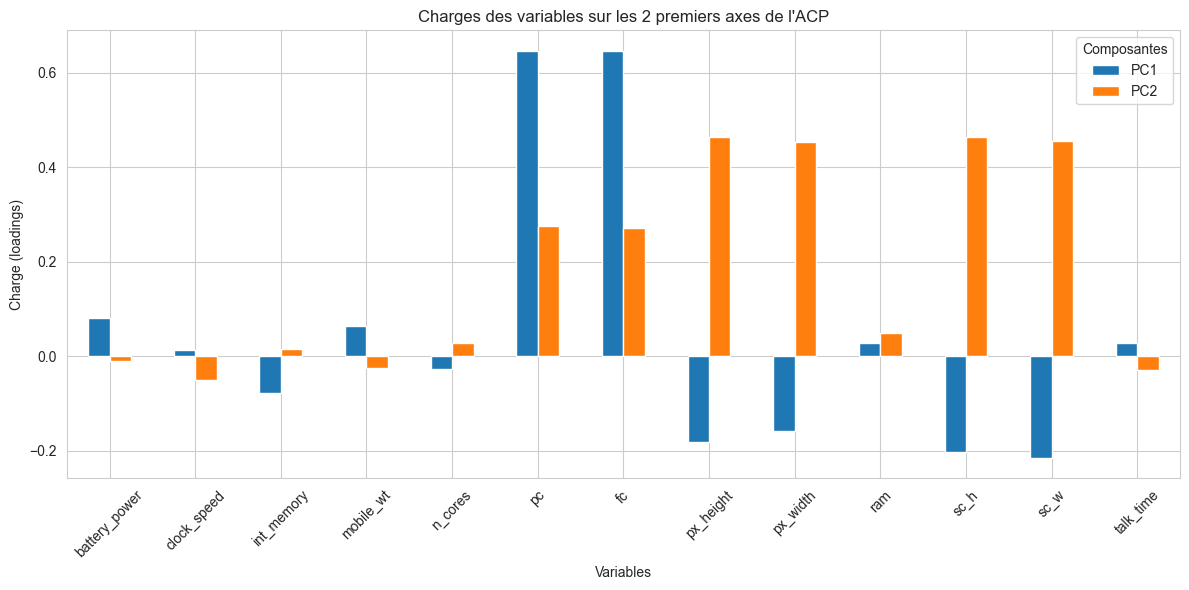

Loadings des variables sur PC1 et PC2 :
                     PC1       PC2
battery_power  0.081065 -0.010236
clock_speed    0.013638 -0.050524
int_memory    -0.077811  0.014401
mobile_wt      0.063293 -0.025868
n_cores       -0.027776  0.027556
pc             0.646017  0.274619
fc             0.646217  0.272013
px_height     -0.181738  0.463971
px_width      -0.158694  0.452393
ram            0.027075  0.048550
sc_h          -0.202922  0.464567
sc_w          -0.215735  0.455297
talk_time      0.028493 -0.029942


In [10]:
# Composantes de la matrice de transformation (les "charges")
components = pca_2.components_

# Création d'un DataFrame des charges pour interprétation
loadings_df = pd.DataFrame(
    components.T,
    columns=[f"PC{i+1}" for i in range(components.shape[0])],
    index=cols_acp
)

plt.figure(figsize=(10, 6))
loadings_df.plot(kind="bar", figsize=(12, 6))
plt.title("Charges des variables sur les 2 premiers axes de l'ACP")
plt.xlabel("Variables")
plt.ylabel("Charge (loadings)")
plt.xticks(rotation=45)
plt.legend(title="Composantes")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

print("Loadings des variables sur PC1 et PC2 :\n", loadings_df)

In [11]:
from sklearn.cluster import KMeans

# K‑means sur les 2 premiers axes de l’ACP
k = 4  # car price_range a 4 classes
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_pca_2)

# Ajouter les clusters au dataset
data_acp = X_scaled[cols_acp].copy()
data_acp["cluster"] = clusters
data_acp["price_range"] = y.values

# Afficher répartition des clusters
print("Répartition des clusters :")
print(data_acp["cluster"].value_counts())

Répartition des clusters :
cluster
3    640
0    523
1    500
2    337
Name: count, dtype: int64


On affiche deux graphiques côte à côte :

d’un côté, les clusters trouvés par k‑means,

de l’autre, les véritables classes de price_range.
Cela permet de comparer la structure découverte par l’ACP + k‑means à la vraie classification des prix.

C:\Users\ousse\AppData\Local\Temp\ipykernel_18752\2753992562.py:25: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\ousse\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


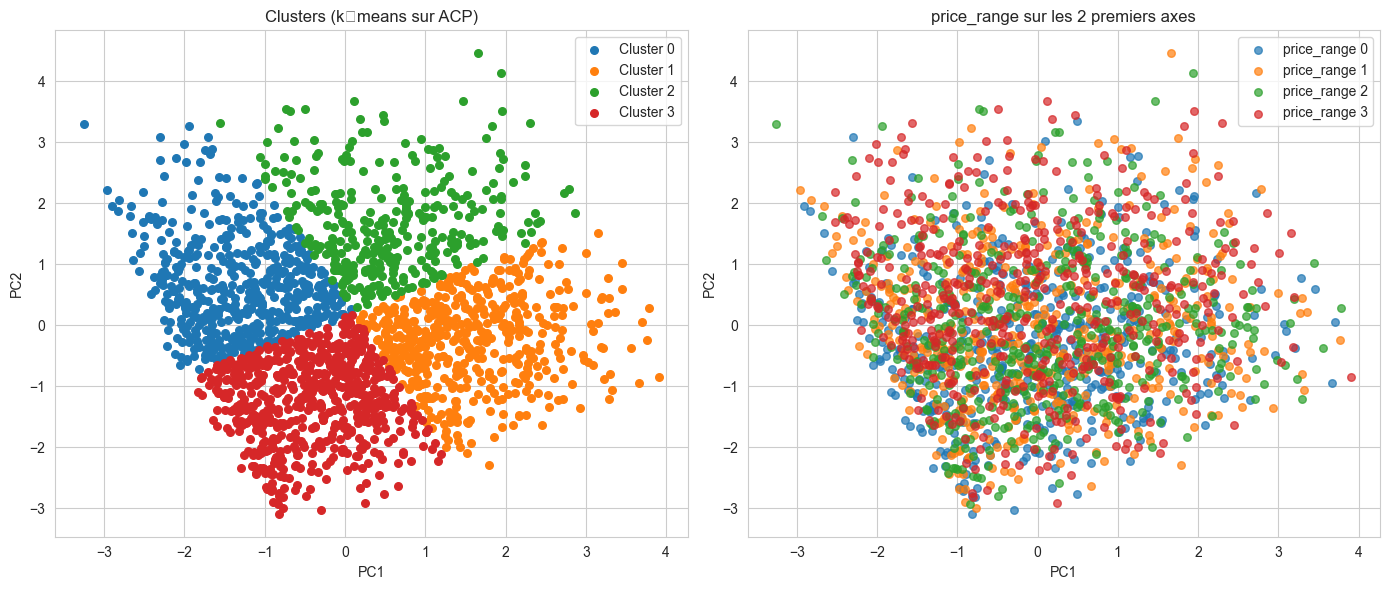

In [12]:
plt.figure(figsize=(14, 6))

# Cluster vs axe 1-2
plt.subplot(1, 2, 1)
for i in range(k):
    mask = (clusters == i)
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1], label=f"Cluster {i}", s=30)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters (k‑means sur ACP)")
plt.legend()
plt.grid(True)

# Clusters colorés par price_range
plt.subplot(1, 2, 2)
for c in sorted(y.unique()):
    mask = (y == c)
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1], label=f"price_range {c}", s=30, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("price_range sur les 2 premiers axes")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()